In [108]:
import numpy as np
from numpy.linalg import norm
from scipy import spatial
import matplotlib.pyplot as plt

In [109]:
def rotate_k_cache_rope(
    k_cache: np.ndarray,
    delta_pos: int,
    rope_theta: float = 10000.0,
) -> np.ndarray:
    """
    将KV Cache中的RoPE位置编码旋转到新的起始位置（NumPy版本）
    
    参数:
        k_cache: 原始Key Cache，格式为(heads, seq_len, head_size)
        delta_pos: 位置改变量（要旋转的角度偏移量）
        rope_theta: RoPE的基础频率参数，默认为10000.0
    
    返回:
        旋转后的KV Cache，格式与输入相同
    """
    if delta_pos == 0:
        return k_cache.copy()
    
    # 获取形状信息
    num_heads, seq_len, head_size = k_cache.shape
    dtype = k_cache.dtype
    
    # 计算旋转角度（Llama风格的RoPE）
    indices = np.arange(0, head_size, 2, dtype=dtype)
    theta = 1.0 / (rope_theta ** (indices / head_size))
    
    # 计算旋转角度
    delta_freq = theta * delta_pos
    
    # 计算旋转矩阵的cos和sin分量
    cos_vals = np.cos(delta_freq)
    sin_vals = np.sin(delta_freq)
    
    # 扩展维度以便广播 (head_size/2) -> (1, 1, head_size/2)
    cos_vals = cos_vals.reshape(1, 1, head_size // 2)
    sin_vals = sin_vals.reshape(1, 1, head_size // 2)
    
    # 将cos和sin值重复以匹配head_size
    cos_vals = np.repeat(cos_vals, 2, axis=-1)
    sin_vals = np.repeat(sin_vals, 2, axis=-1)
    
    # 应用旋转操作
    k_rotated = k_cache * cos_vals + _rotate_half_numpy(k_cache) * sin_vals
    
    return k_rotated

def _rotate_half_numpy(x: np.ndarray) -> np.ndarray:
    """将输入张量的后半部分旋转（NumPy版本）"""
    x1, x2 = np.split(x, 2, axis=-1)
    return np.concatenate((-x2, x1), axis=-1)

In [110]:
kv_recomp = np.load("./saved_kv/recompute.npy")
kv_reuse = np.load("./saved_kv/reuse.npy")
print(kv_recomp.shape, kv_reuse.shape)

(32, 2, 1, 8, 239, 128) (32, 2, 1, 8, 239, 128)


In [111]:
def cos_distance(vec1: np.ndarray, vec2: np.ndarray):
    return spatial.distance.cosine(vec1, vec2)

def l2_distance(vec1: np.ndarray, vec2: np.ndarray):
    return norm(vec1-vec2)

In [112]:
def calc_kv_distance(kv1, kv2, layer, korv, seq, head, metric):
    kv1 = kv1[layer, korv, seq, head]
    kv2 = kv2[layer, korv, seq, head]
    print(kv1.shape)
    pos = 40
    hidden = 2
    half_head_size = kv1.shape[-1] // 2
    # half_head_size = 1
    x1, y1 = kv1[pos][hidden], kv1[pos][hidden + half_head_size]
    x2, y2 = kv2[pos][hidden], kv2[pos][hidden + half_head_size]
    delta = np.arctan(y1 / x1) - np.arctan(y2 / x2)
    print(x1, y1, x2, y2)
    for i in range(10):
        print(round(norm(kv1[pos + i]), 4), end=' ')
    print()
    for i in range(10):
        print(round(norm(kv2[pos + i]), 4), end=' ')
    print()
    print((pos / (1000000.0 ** (hidden / half_head_size)) - delta) / np.pi)
    dis = np.zeros((kv2.shape[0],))
    for i, (vec1, vec2) in enumerate(zip(kv1, kv2)):
        dis[i] = metric(vec1, vec2)
    return dis
dis = calc_kv_distance(kv_recomp, kv_reuse, 0, 0, 0, 0, l2_distance)

(239, 128)
-1.9990234375 2.03515625 0.5810546875 -2.79296875
22.4703 18.8891 18.409 17.8845 20.4541 15.8078 22.3302 17.2428 17.5792 18.6662 
22.4676 18.89 18.407 17.8824 20.454 15.8064 22.3292 17.241 17.5795 18.6657 
8.086325137763874


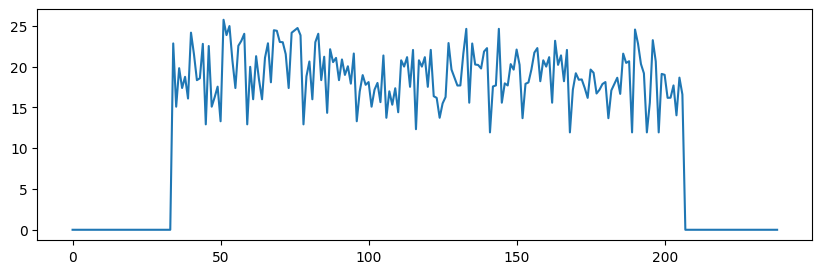

In [113]:
plt.figure(figsize=(10,3))
plt.plot(dis)
plt.show()